# Aim: Fit sim data to omnicron wave 

- Recover 'true burden' and fit linear models if possible

In [1]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import matplotlib.dates as mdates
#print(smf)
import covasim as cv

print(cv.__file__)
print(hasattr(cv, "Sim"))
print(cv.Sim)
import optuna

Covasim 3.1.8 (2026-05-29) — © 2020-2026 by IDM
/storage/hcraddock/GitHub/covasim4wastewater/covasim/__init__.py
True
<class 'covasim.sim.Sim'>


## Data
- Load pre-saved data

In [3]:
OUT = Path.home() / "GitHub" / "covasim_fit_data"     # same folder you saved to

df_pl_weekly = pd.read_pickle(OUT / "df_cases_weekly_pl.pkl")

print(df_pl_weekly.shape)             # expect (102, 8)
#print(df_pl_weekly.columns.tolist())  # week_number, week_start, week_end, n_days, n_distinct_values, weekly_total, week_mid, weekly_total_per_100k
#print(df_pl_weekly.dtypes)            # week_start, week_end, week_mid should be datetime64
df_pl_weekly.head()

(102, 8)


,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [4]:
df_pl_weekly.head()

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
0,1,2021-06-30,2021-07-06,7,1,792.0,2021-07-03,37.426105
1,2,2021-07-07,2021-07-13,7,1,1394.0,2021-07-10,65.873725
2,3,2021-07-14,2021-07-20,7,1,2157.0,2021-07-17,101.929429
3,4,2021-07-21,2021-07-27,7,1,3626.0,2021-07-24,171.347293
4,5,2021-07-28,2021-08-03,7,1,4613.0,2021-07-31,217.988158


In [5]:
df_pl_ww = pd.read_pickle(OUT / "df_ww_pl.pkl")
print(df_pl_ww.dtypes)   
df_pl_ww.head()

Sample_Date                 object
Mean viral gene copies/L     int64
dtype: object


,Sample_Date,Mean viral gene copies/L
0,2/24/21,681730
1,2/28/21,943877
2,3/1/21,1034196
3,3/3/21,1918221
4,3/7/21,770022


In [ ]:
#ALREADY IN DATA
df_pl_ww = df_pl_ww.rename(columns={"Mean viral gene copies/L": "ww_copies_per_L"})]## Convert to date-type
df_pl_ww["Sample_Date"] = pd.to_datetime(df_pl_ww["Sample_Date"], format="%m/%d/%y")
print(df_pl_ww["Sample_Date"].dtype)

#### Plot

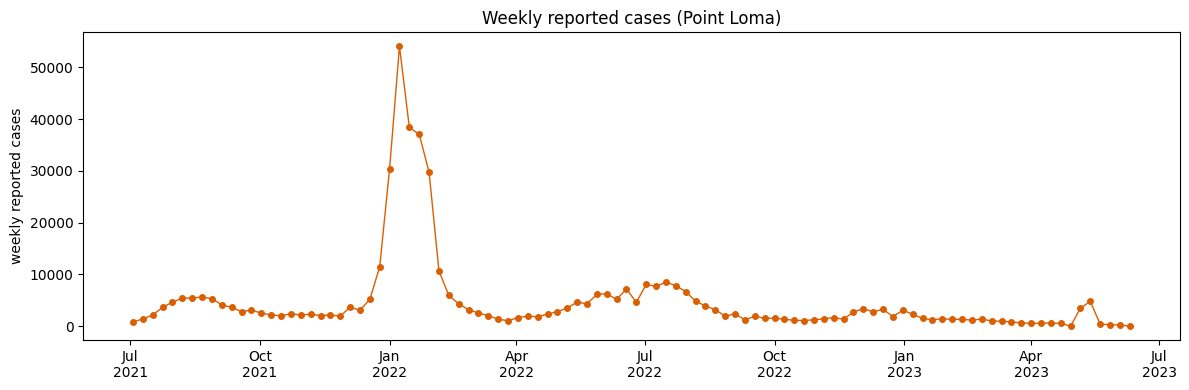

In [10]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_pl_weekly["week_mid"], df_pl_weekly["weekly_total"], "o-", ms=4, lw=1, color="#D95F02")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 3)))   # Jan, Apr, Jul, Oct
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.set_ylabel("weekly reported cases")
ax.set_title("Weekly reported cases (Point Loma)")
plt.tight_layout()
plt.show()

## 2. Omicron Wave

#### I. Case data (omicron)

In [11]:
FIT_START = pd.Timestamp("2021-10-01")
FIT_END   = pd.Timestamp("2022-04-30")

df_omc = df_pl_weekly[(df_pl_weekly["week_start"] >= FIT_START) &
                        (df_pl_weekly["week_end"] <= FIT_END)].copy()

print(len(df_omc), "weeks in the window")
print(df_omc["n_distinct_values"].value_counts())   # mostly 1s; a run of 2s means the grid is drifting

29 weeks in the window
n_distinct_values
1    21
2     6
3     2
Name: count, dtype: int64


In [12]:
df_omc.head()

,week_number,week_start,week_end,n_days,n_distinct_values,weekly_total,week_mid,weekly_total_per_100k
14,15,2021-10-06,2021-10-12,7,1,2156.0,2021-10-09,101.882174
15,16,2021-10-13,2021-10-19,7,1,2002.0,2021-10-16,94.604876
16,17,2021-10-20,2021-10-26,7,1,2385.0,2021-10-23,112.703611
17,18,2021-10-27,2021-11-02,7,1,2155.0,2021-10-30,101.834919
18,19,2021-11-03,2021-11-09,7,1,2293.0,2021-11-06,108.356134


#### II. Waste-water data (omicron)

In [13]:
# Rebuild the window so ww_omc picks up the new name
ww_omc = df_pl_ww[(df_pl_ww["Sample_Date"] >= FIT_START) &
                  (df_pl_ww["Sample_Date"] <= FIT_END)].copy()

In [14]:
ww_omc.head()

,Sample_Date,ww_copies_per_L
87,2021-10-04,248673
88,2021-10-06,218099
89,2021-10-10,248399
90,2021-10-11,409576
91,2021-10-13,653372


In [15]:
print(len(ww_omc), "wastewater samples in the window")

88 wastewater samples in the window


### 2. Sim params

In [19]:
N_SEEDS = 3
W_WW = 1.0

In [20]:
#Get catchment population
CATCHMENT_POP = 2116170

AGENT_POP_SIZE  = 50_000
POP_SCALE = CATCHMENT_POP / AGENT_POP_SIZE

POP_SIZE  = 50_000
POP_SCALE = CATCHMENT_POP / POP_SIZE
N_SEEDS   = 3
W_WW      = 1.0

SIM_START   = pd.Timestamp("2021-11-24")   # warm-up start
SCORE_START = pd.Timestamp("2021-12-08")   # scoring starts


In [21]:
df_fit    = df_omc[df_omc["week_start"] >= SCORE_START].reset_index(drop=True)
cases_obs = df_fit.set_index("week_mid")["weekly_total"].astype(float)
ww_fit    = (ww_omc[ww_omc["Sample_Date"] >= SCORE_START]
               .set_index("Sample_Date")["ww_copies_per_L"].sort_index())
print(len(cases_obs), len(ww_fit))     # expect 22 and about 69 (maybe slightly more, since the start is earlier)

20 62


In [22]:
print(df_fit["week_start"].min().date(), df_fit["week_end"].max().date())  # expect 2021-12-08 to 2022-04-26
print(ww_fit.index.min().date(), ww_fit.index.max().date())

2021-12-08 2022-04-26
2021-12-08 2022-04-27


## 3. Functions

In [23]:
"""
Extract daily (burden, cases, wastewater) time series from a Covasim
simulation, ready for the cases-only / wastewater-only / both linear-model
comparison.

Mapping used:
    burden     -> new_infections   (true, unobserved disease burden)
    cases      -> new_diagnoses    (observed via testing/surveillance)
    wastewater -> sum of viral_shedding_hist across agents, per day

IMPORTANT: `new_diagnoses` will be all zeros unless the sim includes a
testing intervention (e.g. cv.test_prob or cv.test_num). Add one if you
want non-trivial "cases" data.
"""

def extract_wastewater_regression_data(sim) -> pd.DataFrame:
    """
    Parameters
    ----------
    sim : covasim.Sim
        A Sim object that has already been run (sim.run()).

    Returns
    -------
    pd.DataFrame with columns: day, date, burden, cases, wastewater
    """
    results = sim.results

    # --- True burden ------------------------------------------------------
    burden = np.asarray(results['new_infections'].values, dtype=float)

    # --- Case data ----------------------------------------------------------
    if 'new_diagnoses' not in results:
        raise KeyError("sim.results has no 'new_diagnoses' — did the sim run?")
    cases = np.asarray(results['new_diagnoses'].values, dtype=float)
    if cases.sum() == 0:
        print("Warning: 'cases' (new_diagnoses) is all zero. "
              "Add a testing intervention, e.g. cv.test_prob(...), to the sim.")

    # --- Wastewater signal ------------------------------------------------
    viral_shedding_hist = np.asarray(results['viral_shedding_hist'])  # (n_people, n_days)
    wastewater = viral_shedding_hist.sum(axis=0)

    n = len(burden)
    df = pd.DataFrame({
        'day': np.arange(n),
        'date': [sim.date(d) for d in range(n)],
        'burden': burden,
        'cases': cases,
        'wastewater': wastewater[:n],
    })
    return df

In [24]:
def run_sim(beta, symp_prob, pop_infected, immune_frac=0.0, seed=0):
    """Run one Covasim sim and return it.

    beta         : transmission rate per contact
    symp_prob    : daily probability a symptomatic person is tested
    pop_infected : agents infected on day 1 (each represents POP_SCALE real people)
    immune_frac  : fraction of agents made completely immune (prior infection / vaccination).
                   Shrinks the susceptible pool without slowing early growth.
    seed         : random seed
    """
    testing = cv.test_prob(symp_prob=symp_prob, asymp_prob=0.001, test_delay=1)

    s = cv.Sim(
        pop_size=POP_SIZE, pop_scale=POP_SCALE, pop_type='hybrid', location='usa',
        beta=beta, pop_infected=pop_infected, n_imports=0,
        start_day=SIM_START, end_day=FIT_END,
        interventions=[testing], rand_seed=seed, verbose=0,
    )
    s.initialize()

    # Make a random share of agents unable to be infected (rel_sus = 0)
    rng = np.random.default_rng(seed + 1000)              # separate stream from the sim's own seed
    immune = rng.random(len(s.people)) < immune_frac
    s.people.rel_sus[immune] = 0.0

    s.run()
    return s

In [25]:
# ---- Run several seeds, return averaged weekly cases and wastewater as date-indexed Series ----
def sim_outputs(beta, symp_prob, pop_infected, n_seeds=N_SEEDS):
    """Run n_seeds stochastic sims at one parameter setting and average them.

    beta         : transmission rate (from Optuna)
    symp_prob    : daily probability a symptomatic person is tested (from Optuna)
    pop_infected : agents infected on day 1 (from Optuna)
    n_seeds      : how many random seeds to average (reduces sim noise)

    Returns (sim_wk, sim_ww): Series with the same indexes as cases_obs and ww_fit.
    """
    wk, ww = [], []   # one Series per seed

    for seed in range(n_seeds):
        s = run_sim(beta=beta, symp_prob=symp_prob,
                    pop_infected=pop_infected,
                    rel_sus=1.0,                      # fixed: fully susceptible (not fitted)
                    seed=seed)

        # Weekly sim cases, labelled with the same week_mid dates as cases_obs
        wk.append(pd.Series(weekly_sim(s, df_fit), index=cases_obs.index))

        d = extract_wastewater_regression_data(s)     # assumes columns 'date' and 'wastewater'
        d["date"] = pd.to_datetime(d["date"])
        # Sim wastewater, kept only on days with a real sample (index = ww_fit dates)
        ww.append(d.set_index("date")["wastewater"].reindex(ww_fit.index))

    # Average across seeds; result keeps the date index
    sim_wk = pd.concat(wk, axis=1).mean(axis=1)
    sim_ww = pd.concat(ww, axis=1).mean(axis=1)
    return sim_wk, sim_ww


# ---- Loss ----
def compute_loss(sim_wk, sim_ww):
    """Compare sim to real data. Lower = better fit.

    sim_wk : Series of sim weekly cases (index = week_mid dates)
    sim_ww : Series of sim wastewater (index = real sample dates)
    Uses globals cases_obs and ww_fit.
    """
    # Align by date so the two series can't be silently misordered
    sim_wk, obs_wk = sim_wk.align(cases_obs, join="inner")
    sim_w,  obs_w  = sim_ww.align(ww_fit,   join="inner")

    # Cases: absolute level matters (symp_prob sets the reporting fraction)
    loss_c = np.sqrt(np.mean((np.log1p(sim_wk) - np.log1p(obs_wk)) ** 2))

    # Wastewater: shape and timing only. Subtracting the mean log-difference
    # removes the unknown scale factor (std of the residual).
    eps = 1e-3 * sim_w.max() + 1e-12                  # tiny offset so log() never sees zero
    r = np.log(sim_w + eps) - np.log(obs_w)           # log-difference per sample date
    r = r[np.isfinite(r)]
    loss_w = r.std(ddof=0)                            # ddof=0 matches np.std
    return loss_c, loss_w


# ---- Optuna objective ----
def objective(trial):
    """One Optuna trial: pick parameters, run sims, return the loss to minimise."""
    beta         = trial.suggest_float("beta", 0.015, 0.06)
    symp_prob    = trial.suggest_float("symp_prob", 0.01, 0.3, log=True)
    pop_infected = trial.suggest_int("pop_infected", 100, 900)

    sim_wk, sim_ww = sim_outputs(beta, symp_prob, pop_infected)

    if sim_wk.sum() < 1 or sim_ww.notna().sum() == 0 or sim_ww.max() <= 0:
        return 10.0                                   # outbreak fizzled: heavy penalty

    loss_c, loss_w = compute_loss(sim_wk, sim_ww)
    trial.set_user_attr("loss_cases", float(loss_c))
    trial.set_user_attr("loss_ww", float(loss_w))
    return loss_c + W_WW * loss_w

In [27]:
def compute_loss(sim_wk, sim_ww):
    """Compare sim to real data. Lower = better fit.

    sim_wk : Series of sim weekly cases (index = week_mid dates)
    sim_ww : Series of sim wastewater (index = real sample dates)
    Uses globals cases_obs and ww_fit.
    """
    # Align by date so the two series can't be silently misordered
    sim_wk, obs_wk = sim_wk.align(cases_obs, join="inner")
    sim_w,  obs_w  = sim_ww.align(ww_fit,   join="inner")

    # Cases: absolute level matters (symp_prob sets the reporting fraction)
    loss_c = np.sqrt(np.mean((np.log1p(sim_wk) - np.log1p(obs_wk)) ** 2))

    # Wastewater: shape and timing only. Subtracting the mean log-difference
    # removes the unknown scale factor (std of the residual).
    eps = 1e-3 * sim_w.max() + 1e-12
    r = np.log(sim_w + eps) - np.log(obs_w)
    r = r[np.isfinite(r)]
    loss_w = r.std(ddof=0)
    return loss_c, loss_w

In [34]:
def weekly_sim(s, weeks):
    """Sum the sim's daily new_diagnoses over each reporting week.

    s     : a finished sim
    weeks : table with week_start and week_end columns (here df_fit)
    Returns a list of simulated weekly case totals, one per row of `weeks`.
    """
    daily = pd.Series(s.results["new_diagnoses"].values,
                      index=pd.to_datetime(s.datevec))
    return [daily.loc[a:b].sum() for a, b in zip(weeks["week_start"], weeks["week_end"])]

### Plot Data

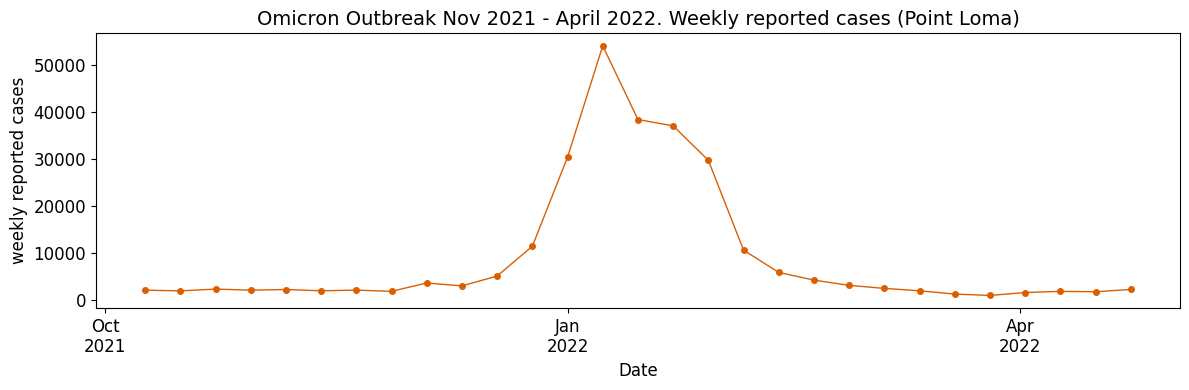

In [29]:

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(df_omc["week_mid"], df_omc["weekly_total"], "o-", ms=4, lw=1, color="#D95F02")

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=range(1, 13, 3)))   # Jan, Apr, Jul, Oct
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))

ax.set_ylabel("weekly reported cases", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.set_title("Omicron Outbreak Nov 2021 - April 2022. Weekly reported cases (Point Loma)", fontsize=14)
ax.tick_params(axis="both", labelsize=12)

plt.tight_layout()
plt.show()

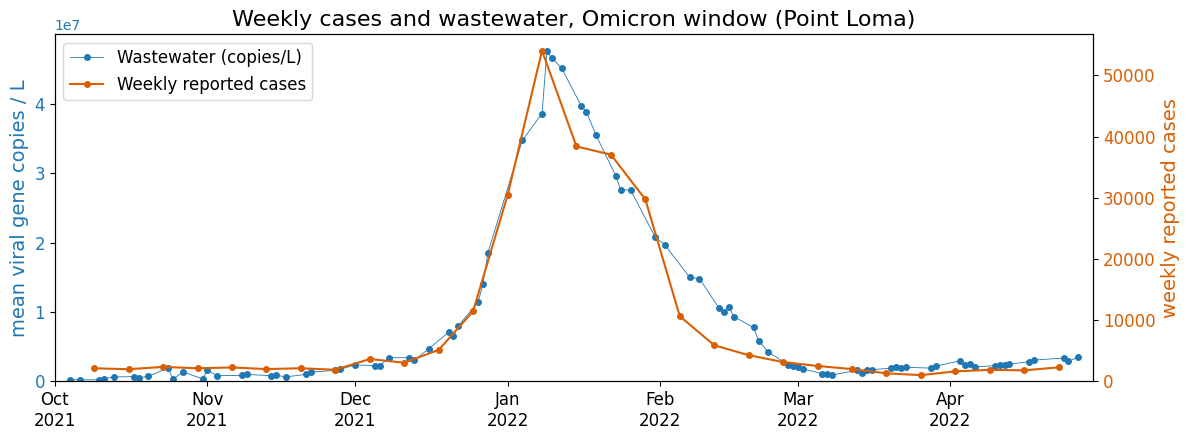

In [21]:
fig, ax = plt.subplots(figsize=(12, 4.5))

# Left axis: wastewater
c_ww = "tab:blue"
l1, = ax.plot(ww_omc["Sample_Date"], ww_omc["ww_copies_per_L"], ".-", ms=8, lw=0.6,
              color=c_ww, label="Wastewater (copies/L)")
ax.set_ylabel("mean viral gene copies / L", color=c_ww, fontsize=14)
ax.tick_params(axis="y", labelcolor=c_ww, labelsize=12)
ax.set_ylim(bottom=0)

# Right axis: weekly cases, plotted at the middle of each week
ax2 = ax.twinx()
c_cases = "#D95F02"
l2, = ax2.plot(df_omc["week_mid"], df_omc["weekly_total"], "o-", ms=4, lw=1.5,
               color=c_cases, label="Weekly reported cases")
ax2.set_ylabel("weekly reported cases", color=c_cases, fontsize=14)
ax2.tick_params(axis="y", labelcolor=c_cases, labelsize=12)
ax2.set_ylim(bottom=0)

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax.tick_params(axis="x", labelsize=12)
ax.set_xlim(FIT_START, FIT_END)

ax.set_title("Weekly cases and wastewater, Omicron window (Point Loma)", fontsize=16)
ax.legend(handles=[l1, l2], loc="upper left", fontsize=12)
plt.tight_layout()
plt.show()

In [32]:
def sim_outputs(beta, symp_prob, pop_infected, immune_frac, n_seeds=N_SEEDS):
    wk, ww = [], []
    for seed in range(n_seeds):
        s = run_sim(beta, symp_prob, pop_infected, immune_frac, seed=seed)
        wk.append(pd.Series(weekly_sim(s, df_fit), index=cases_obs.index))

        d = extract_wastewater_regression_data(s)
        d["date"] = pd.to_datetime(d["date"])
        ww.append(d.set_index("date")["wastewater"].reindex(ww_fit.index))
    return pd.concat(wk, axis=1).mean(axis=1), pd.concat(ww, axis=1).mean(axis=1)

## RE-RUN BEST PARAMS

In [31]:
import inspect
print(inspect.signature(sim_outputs))

(beta, symp_prob, pop_infected, n_seeds=3)


{'beta': 0.18259837529898848, 'symp_prob': 0.06312866052882372, 'pop_infected': 227, 'immune_frac': 0.6755786853082207}
{'loss_cases': 0.5053721011927973, 'loss_ww': 0.6160777223796299}
Fit 3 (trial 0): 2.2314181650551044 {'loss_cases': 1.1774756284344894, 'loss_ww': 1.053942536620615}

In [35]:
bp = {"beta": 0.1826, "symp_prob": 0.0631, "pop_infected": 227, "immune_frac": 0.6756}
sim_wk, sim_ww = sim_outputs(bp["beta"], bp["symp_prob"], bp["pop_infected"], bp["immune_frac"], n_seeds=5)
print(compute_loss(sim_wk, sim_ww))   # expect roughly (0.5, 0.6)

(1.693865598949388, 0.7384813546413562)


In [ ]:
sim_outputs()

In [27]:
for name in ["extract_wastewater_regression_data", "run_sim", "weekly_sim", "sim_outputs", "compute_loss"]:
    print(name, name in globals())

extract_wastewater_regression_data True
run_sim True
weekly_sim True
sim_outputs True
compute_loss True


In [ ]:
for start in ["2021-12-08", "2021-11-24"]:
    SIM_START = pd.Timestamp(start)
    wk3, ww3 = sim_outputs(bp["beta"], bp["symp_prob"], bp["pop_infected"], bp["immune_frac"], n_seeds=3)
    print(start, compute_loss(wk3, ww3))

## Plot Best Params

In [36]:
SIM_START = pd.Timestamp("2021-11-24")

bp = {'beta': 0.18259837529898848, 'symp_prob': 0.06312866052882372,
      'pop_infected': 227, 'immune_frac': 0.6755786853082207}

# Same 3 seeds as the search
sim_wk, sim_ww = sim_outputs(bp["beta"], bp["symp_prob"], bp["pop_infected"], bp["immune_frac"], n_seeds=3)
print(compute_loss(sim_wk, sim_ww))      # expect about (0.51, 0.62)

(0.5053721011927973, 0.6204321820715306)


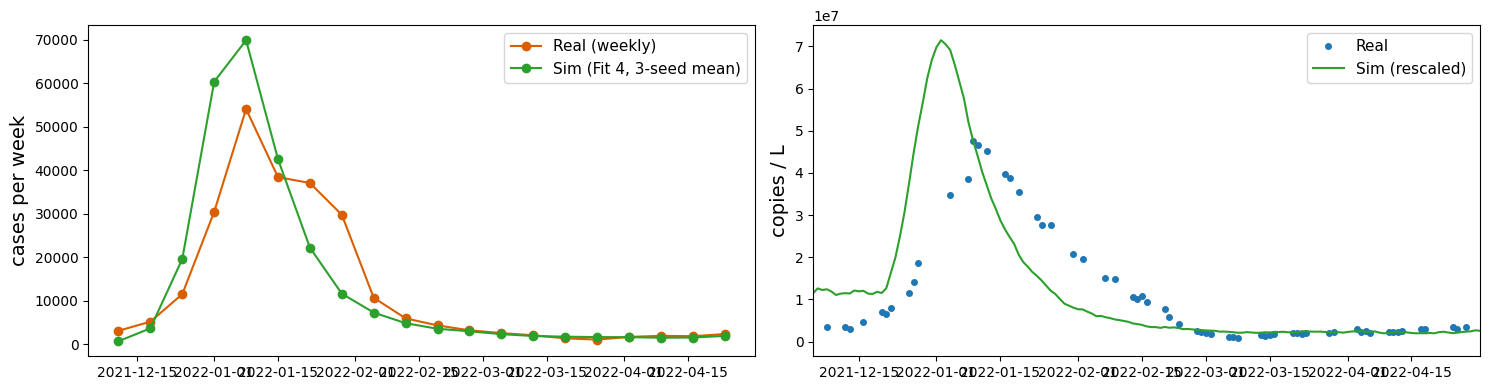

In [37]:
# Daily wastewater curve from seed 0, scaled by the constant from the 3-seed mean
eps = 1e-3 * sim_ww.max() + 1e-12
scale = np.exp(np.mean(np.log(ww_fit.values) - np.log(sim_ww.values + eps)))

s = run_sim(bp["beta"], bp["symp_prob"], bp["pop_infected"], bp["immune_frac"], seed=0)
d = extract_wastewater_regression_data(s)
d["date"] = pd.to_datetime(d["date"])
sim_ww_daily = d.set_index("date")["wastewater"]

fig, ax = plt.subplots(1, 2, figsize=(15, 4))

ax[0].plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")
ax[0].plot(sim_wk.index, sim_wk.values, "o-", color="tab:green", label="Sim (Fit 4, 3-seed mean)")
ax[0].set_ylabel("cases per week", fontsize=14)
ax[0].legend(fontsize=11)

ax[1].plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax[1].plot(sim_ww_daily.index, (sim_ww_daily + eps) * scale, "-", color="tab:green", label="Sim (rescaled)")
ax[1].set_xlim(ww_fit.index.min() - pd.Timedelta(days=3), ww_fit.index.max() + pd.Timedelta(days=3))
ax[1].set_ylabel("copies / L", fontsize=14)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

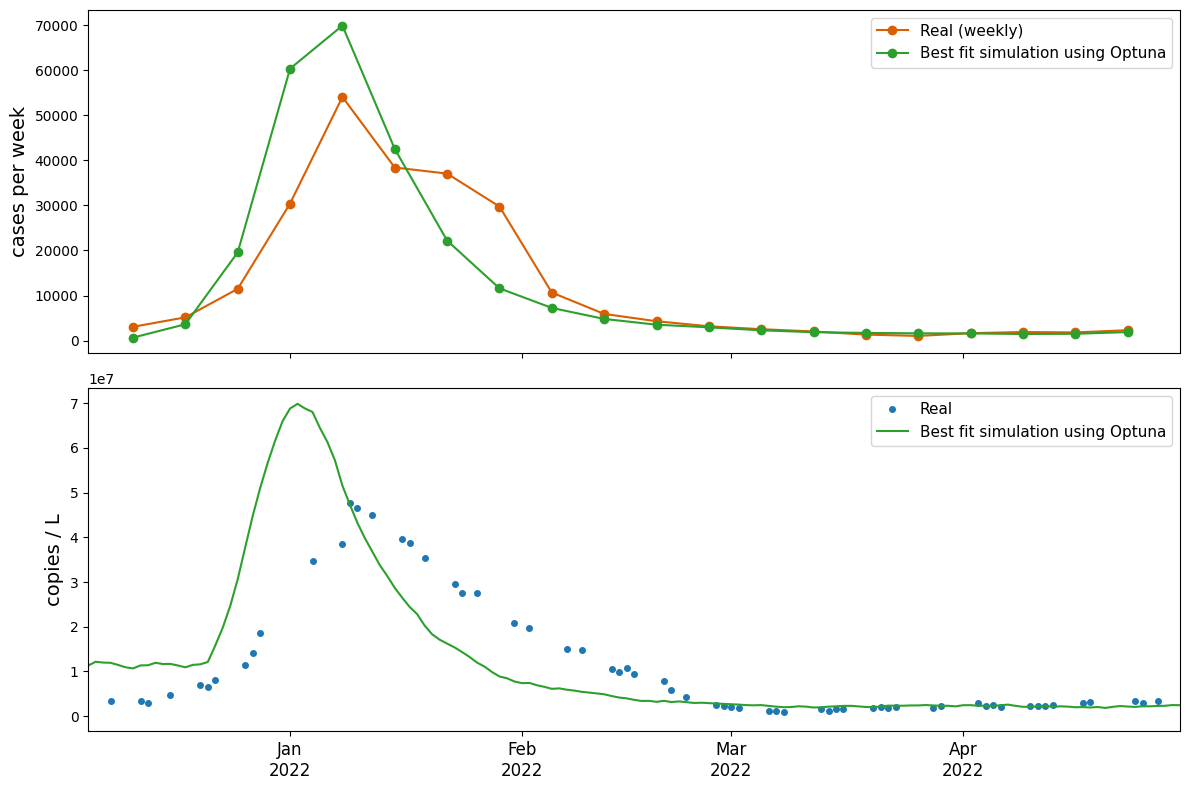

In [34]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top: weekly cases
ax[0].plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")
ax[0].plot(sim_wk.index, sim_wk.values, "o-", color="tab:green", label="Best fit simulation using Optuna")
ax[0].set_ylabel("cases per week", fontsize=14)
ax[0].legend(fontsize=11)

# Bottom: wastewater
ax[1].plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax[1].plot(sim_ww_daily.index, (sim_ww_daily + eps) * scale, "-", color="tab:green", label="Best fit simulation using Optuna")
ax[1].set_ylabel("copies / L", fontsize=14)
ax[1].legend(fontsize=11)

# Shared x-axis: one tick per month, so labels don't collide
ax[1].set_xlim(ww_fit.index.min() - pd.Timedelta(days=3), ww_fit.index.max() + pd.Timedelta(days=3))
ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax[1].tick_params(axis="x", labelsize=12)

plt.tight_layout()
plt.show()

In [35]:
def sim_outputs(beta, symp_prob, pop_infected, immune_frac, ww_lag_days=0, n_seeds=N_SEEDS):
    """Average n_seeds sims; shift sim wastewater by ww_lag_days before sampling it on real dates.

    ww_lag_days : days the sim wastewater is delayed (sim date t is compared with real date t + lag)
    """
    wk, ww = [], []
    for seed in range(n_seeds):
        s = run_sim(beta, symp_prob, pop_infected, immune_frac, seed=seed)
        wk.append(pd.Series(weekly_sim(s, df_fit), index=cases_obs.index))

        d = extract_wastewater_regression_data(s)
        d["date"] = pd.to_datetime(d["date"])
        daily = d.set_index("date")["wastewater"]

        # Delay the daily curve, THEN pick the real sample dates
        daily = daily.shift(int(ww_lag_days), freq="D")
        ww.append(daily.reindex(ww_fit.index))

    return pd.concat(wk, axis=1).mean(axis=1), pd.concat(ww, axis=1).mean(axis=1)

In [36]:
def objective(trial):
    beta         = trial.suggest_float("beta", 0.08, 0.25)
    symp_prob    = trial.suggest_float("symp_prob", 0.01, 0.3, log=True)
    pop_infected = trial.suggest_int("pop_infected", 100, 3000, log=True)
    immune_frac  = trial.suggest_float("immune_frac", 0.5, 0.8)
    ww_lag_days  = trial.suggest_int("ww_lag_days", 0, 10)

    sim_wk, sim_ww = sim_outputs(beta, symp_prob, pop_infected, immune_frac, ww_lag_days)

    if sim_wk.sum() < 1 or sim_ww.notna().sum() < 10 or sim_ww.max() <= 0:
        return 10.0

    loss_c, loss_w = compute_loss(sim_wk, sim_ww)
    trial.set_user_attr("loss_cases", float(loss_c))
    trial.set_user_attr("loss_ww", float(loss_w))
    return loss_c + W_WW * loss_w

In [37]:
study5 = optuna.create_study(
    study_name="pl_omicron_fit5_lag",
    storage=f"sqlite:///{OUT / 'optuna_pl_lag.db'}",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
        load_if_exists=True,
)
study5.enqueue_trial({"beta": 0.1826, "symp_prob": 0.0631, "pop_infected": 227,
                      "immune_frac": 0.6756, "ww_lag_days": 5})
study5.optimize(objective, n_trials=100, show_progress_bar=True)
print(study5.best_params, study5.best_value, study5.best_trial.user_attrs)

[I 2026-10-01 17:27:15,767] A new study created in RDB with name: pl_omicron_fit5_lag


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 17:27:34,475] Trial 0 finished with value: 1.0922130620669264 and parameters: {'beta': 0.1826, 'symp_prob': 0.0631, 'pop_infected': 227, 'immune_frac': 0.6756, 'ww_lag_days': 5}. Best is trial 0 with value: 1.0922130620669264.
[I 2026-10-01 17:27:52,668] Trial 1 finished with value: 2.2484602519977424 and parameters: {'beta': 0.14367182020405161, 'symp_prob': 0.2536999076681772, 'pop_infected': 1204, 'immune_frac': 0.679597545259111, 'ww_lag_days': 1}. Best is trial 0 with value: 1.0922130620669264.
[I 2026-10-01 17:28:10,857] Trial 2 finished with value: 3.5245923026281814 and parameters: {'beta': 0.10651906845715445, 'symp_prob': 0.012184186502221764, 'pop_infected': 1902, 'immune_frac': 0.6803345035229627, 'ww_lag_days': 7}. Best is trial 0 with value: 1.0922130620669264.
[I 2026-10-01 17:28:29,654] Trial 3 finished with value: 2.64617871591388 and parameters: {'beta': 0.08349936403028642, 'symp_prob': 0.2708160864249968, 'pop_infected': 1696, 'immune_frac': 0.56370173

In [38]:
   tdf = study5.trials_dataframe()
   print(tdf.nsmallest(10, "value")[["number", "value", "params_beta", "params_symp_prob",
         "params_pop_infected", "params_immune_frac", "params_ww_lag_days"]])

    number     value  params_beta  params_symp_prob  params_pop_infected  \
81      81  0.989776     0.143958          0.070712                  241   
95      95  0.997780     0.147871          0.060525                  235   
44      44  0.999478     0.102974          0.057656                  238   
93      93  0.999698     0.140087          0.049845                  231   
80      80  1.001983     0.137343          0.059729                  207   
87      87  1.002079     0.149053          0.064932                  232   
99      99  1.010865     0.136208          0.057726                  219   
52      52  1.011748     0.131288          0.051026                  257   
91      91  1.012004     0.137681          0.081663                  264   
96      96  1.013429     0.150482          0.076286                  193   

    params_immune_frac  params_ww_lag_days  
81            0.592066                   9  
95            0.611710                   9  
44            0.505088      

In [40]:
study5 = optuna.load_study(
    study_name="pl_omicron_fit5_lag",
    storage=f"sqlite:///{OUT / 'optuna_pl_lag.db'}",
)
print(len(study5.trials), study5.best_value)   # expect 100 and about 0.990

100 0.9897755528652036


In [41]:
for name in ["run_sim", "weekly_sim", "extract_wastewater_regression_data",
             "df_fit", "cases_obs", "ww_fit", "study5"]:
    print(name, name in globals())

run_sim True
weekly_sim True
extract_wastewater_regression_data True
df_fit True
cases_obs True
ww_fit True
study5 True


In [44]:
top = tdf.nsmallest(1, "value")      # in place of nsmallest(5, "value")

In [45]:
import pickle
pickle.dump(results, open(OUT / "fit5_top5_curves.pkl", "wb"))

NameError: name 'results' is not defined

## Best Wastewater

In [38]:
def sim_outputs2(beta, symp_prob, pop_infected, immune_frac, ww_lag_days, case_lag_days,
                 seeds=(0, 1, 2)):
    wk, ww = [], []
    for seed in seeds:
        s = run_sim(beta, symp_prob, pop_infected, immune_frac, seed=seed)

        # Cases: delay daily diagnoses, then sum over the real reporting weeks
        cases_daily = pd.Series(s.results["new_diagnoses"].values,
                                index=pd.to_datetime(s.datevec))
        cases_daily = cases_daily.shift(int(case_lag_days), freq="D")
        wk.append(pd.Series([cases_daily.loc[a:b].sum()
                             for a, b in zip(df_fit["week_start"], df_fit["week_end"])],
                            index=cases_obs.index))

        # Wastewater: delay the daily curve, then sample on real dates
        d = extract_wastewater_regression_data(s)
        d["date"] = pd.to_datetime(d["date"])
        daily = d.set_index("date")["wastewater"].shift(int(ww_lag_days), freq="D")
        ww.append(daily.reindex(ww_fit.index))
    return pd.concat(wk, axis=1).mean(axis=1), pd.concat(ww, axis=1).mean(axis=1)


W_PEAK = 1.0   # weight on the peak-height error

def compute_loss2(sim_wk, sim_ww):
    loss_c, loss_w = compute_loss(sim_wk, sim_ww)          # your existing log losses
    s_wk, o_wk = sim_wk.align(cases_obs, join="inner")
    loss_peak = abs(np.log((s_wk.max() + 1) / (o_wk.max() + 1)))   # 0 = peak height matches
    return loss_c, loss_w, loss_peak


def objective2(trial):
    beta          = trial.suggest_float("beta", 0.08, 0.25)
    symp_prob     = trial.suggest_float("symp_prob", 0.01, 0.3, log=True)
    pop_infected  = trial.suggest_int("pop_infected", 100, 3000, log=True)
    immune_frac   = trial.suggest_float("immune_frac", 0.4, 0.8)
    ww_lag_days   = trial.suggest_int("ww_lag_days", 0, 5)        # capped
    case_lag_days = trial.suggest_int("case_lag_days", 0, 10)     # reporting delay

    # different seeds each trial, so the search can't tune to one set of seeds
    seeds = range(trial.number * 3, trial.number * 3 + 3)
    sim_wk, sim_ww = sim_outputs2(beta, symp_prob, pop_infected, immune_frac,
                                  ww_lag_days, case_lag_days, seeds)

    if sim_wk.sum() < 1 or sim_ww.notna().sum() < 10 or sim_ww.max() <= 0:
        return 10.0

    lc, lw, lp = compute_loss2(sim_wk, sim_ww)
    for k, v in [("loss_cases", lc), ("loss_ww", lw), ("loss_peak", lp)]:
        trial.set_user_attr(k, float(v))
    return lc + W_WW * lw + W_PEAK * lp

In [ ]:
study6 = optuna.create_study(
    study_name="pl_omicron_fit6_joint",
    storage=f"sqlite:///{OUT / 'optuna_pl_joint.db'}",
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
    load_if_exists=True,
)
study6.optimize(objective2, n_trials=100, show_progress_bar=True)
print(study6.best_params, study6.best_value, study6.best_trial.user_attrs)

[I 2026-10-01 19:14:01,857] A new study created in RDB with name: pl_omicron_fit6_joint


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-10-01 19:14:20,626] Trial 0 finished with value: 3.0006846849879443 and parameters: {'beta': 0.14367182020405161, 'symp_prob': 0.2536999076681772, 'pop_infected': 1204, 'immune_frac': 0.6394633936788147, 'ww_lag_days': 0, 'case_lag_days': 1}. Best is trial 0 with value: 3.0006846849879443.
[I 2026-10-01 19:14:39,120] Trial 1 finished with value: 2.7213907981896464 and parameters: {'beta': 0.08987421406859392, 'symp_prob': 0.19030368381735815, 'pop_infected': 771, 'immune_frac': 0.6832290311184182, 'ww_lag_days': 0, 'case_lag_days': 10}. Best is trial 1 with value: 2.7213907981896464.
[I 2026-10-01 19:14:59,581] Trial 2 finished with value: 2.2069395813963073 and parameters: {'beta': 0.22151524893607166, 'symp_prob': 0.020589728197687916, 'pop_infected': 185, 'immune_frac': 0.47336180394137356, 'ww_lag_days': 1, 'case_lag_days': 5}. Best is trial 2 with value: 2.2069395813963073.
[I 2026-10-01 19:15:20,026] Trial 3 finished with value: 2.1080971695500743 and parameters: {'beta':

In [39]:
OUT = Path.home() / "GitHub" / "covasim_fit_data"     # needed if the kernel restarted

study6 = optuna.load_study(study_name="pl_omicron_fit6_joint",
                           storage=f"sqlite:///{OUT / 'optuna_pl_joint.db'}")
print(len(study6.trials), study6.best_value)

100 1.3507154304886673


In [40]:
print(study6.best_params)
print(study6.best_trial.user_attrs)    # loss_cases, loss_ww, loss_peak

{'beta': 0.09809881774946815, 'symp_prob': 0.022382681901734938, 'pop_infected': 365, 'immune_frac': 0.4459472491299481, 'ww_lag_days': 0, 'case_lag_days': 2}
{'loss_cases': 0.7044916410309252, 'loss_peak': 0.00016480431758904477, 'loss_ww': 0.6460589851401531}


In [41]:
bp6 = study6.best_params

wk6, ww6 = sim_outputs2(bp6["beta"], bp6["symp_prob"], bp6["pop_infected"], bp6["immune_frac"],
                        bp6["ww_lag_days"], bp6["case_lag_days"], seeds=(0, 1, 2))
print(compute_loss2(wk6, ww6))

# Daily wastewater curve (seed 0), lagged, rescaled by one constant fitted on the real sample dates
s = run_sim(bp6["beta"], bp6["symp_prob"], bp6["pop_infected"], bp6["immune_frac"], seed=0)
d = extract_wastewater_regression_data(s)
d["date"] = pd.to_datetime(d["date"])
ww_daily = d.set_index("date")["wastewater"].shift(int(bp6["ww_lag_days"]), freq="D")

on = ww_daily.reindex(ww_fit.index)
ok = on.notna() & (on > 0)
scale = np.exp(np.mean(np.log(ww_fit[ok].values) - np.log(on[ok].values)))

(0.6459981223726324, 0.6239709229520263, 0.01913235282179855)


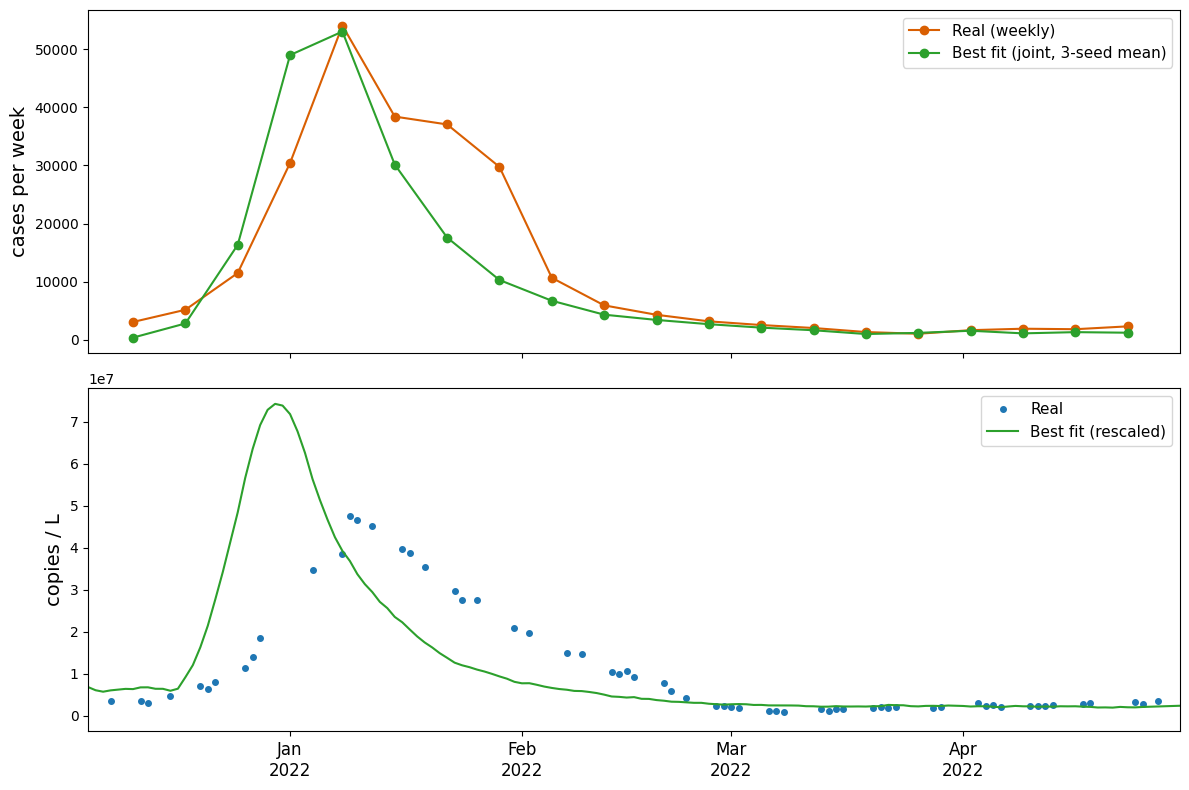

In [42]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

ax[0].plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")
ax[0].plot(wk6.index, wk6.values, "o-", color="tab:green", label="Best fit (joint, 3-seed mean)")
ax[0].set_ylabel("cases per week", fontsize=14)
ax[0].legend(fontsize=11)

ax[1].plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax[1].plot(ww_daily.index, ww_daily * scale, "-", color="tab:green", label="Best fit (rescaled)")
ax[1].set_ylabel("copies / L", fontsize=14)
ax[1].legend(fontsize=11)

ax[1].set_xlim(ww_fit.index.min() - pd.Timedelta(days=3), ww_fit.index.max() + pd.Timedelta(days=3))
ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
ax[1].tick_params(axis="x", labelsize=12)
plt.tight_layout()
plt.show()

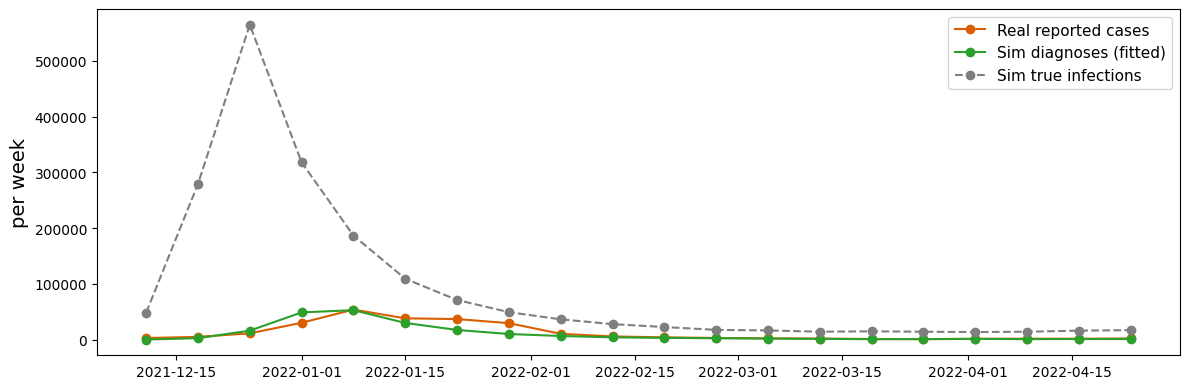

In [43]:
# Weekly true infections (3-seed mean) vs weekly diagnoses, both in real-people units
inf, dia = [], []
for seed in range(3):
    s = run_sim(bp6["beta"], bp6["symp_prob"], bp6["pop_infected"], bp6["immune_frac"], seed=seed)
    idx = pd.to_datetime(s.datevec)
    daily_inf = pd.Series(s.results["new_infections"].values, index=idx)
    inf.append(pd.Series([daily_inf.loc[a:b].sum() for a, b in zip(df_fit["week_start"], df_fit["week_end"])],
                         index=cases_obs.index))
inf = pd.concat(inf, axis=1).mean(axis=1)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real reported cases")
ax.plot(wk6.index, wk6.values, "o-", color="tab:green", label="Sim diagnoses (fitted)")
ax.plot(inf.index, inf.values, "o--", color="tab:gray", label="Sim true infections")
ax.set_ylabel("per week", fontsize=14)
ax.legend(fontsize=11)
plt.tight_layout(); plt.show()

## FIX TRUE INFECTIONS

A: symp 0.20, imm 0.75, beta 0.20: total infections 647,308 of 2,116,170, ascertainment 51%, diag peak 92,773
B: symp 0.30, imm 0.80, beta 0.25: total infections 480,452 of 2,116,170, ascertainment 58%, diag peak 70,849
C: symp 0.30, imm 0.85, beta 0.30: total infections 319,037 of 2,116,170, ascertainment 58%, diag peak 36,991


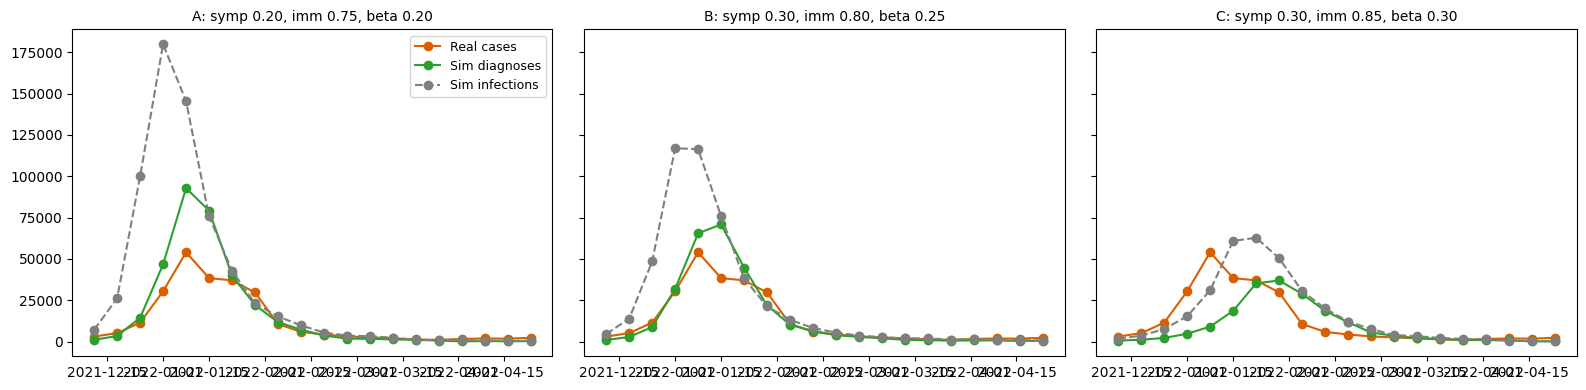

In [44]:
SIM_START = pd.Timestamp("2021-11-24")

variants = {
    "A: symp 0.20, imm 0.75, beta 0.20": dict(beta=0.20, symp_prob=0.20, pop_infected=227, immune_frac=0.75),
    "B: symp 0.30, imm 0.80, beta 0.25": dict(beta=0.25, symp_prob=0.30, pop_infected=227, immune_frac=0.80),
    "C: symp 0.30, imm 0.85, beta 0.30": dict(beta=0.30, symp_prob=0.30, pop_infected=227, immune_frac=0.85),
}

fig, ax = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for a, (name, p) in zip(ax, variants.items()):
    s = run_sim(**p, seed=0)
    idx = pd.to_datetime(s.datevec)
    dia = pd.Series(s.results["new_diagnoses"].values, index=idx)
    inf = pd.Series(s.results["new_infections"].values, index=idx)
    wk_d = pd.Series([dia.loc[x:y].sum() for x, y in zip(df_fit["week_start"], df_fit["week_end"])], index=cases_obs.index)
    wk_i = pd.Series([inf.loc[x:y].sum() for x, y in zip(df_fit["week_start"], df_fit["week_end"])], index=cases_obs.index)

    a.plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real cases")
    a.plot(wk_d.index, wk_d.values, "o-", color="tab:green", label="Sim diagnoses")
    a.plot(wk_i.index, wk_i.values, "o--", color="tab:gray", label="Sim infections")
    a.set_title(name, fontsize=10)
    print(f"{name}: total infections {inf.sum():,.0f} of {CATCHMENT_POP:,}, "
          f"ascertainment {dia.sum()/max(inf.sum(),1):.0%}, diag peak {wk_d.max():,.0f}")
ax[0].legend(fontsize=9)
plt.tight_layout(); plt.show()

## Fix Waste-water

0     0.624
1     0.579
2     0.537
3     0.507
4     0.482
5     0.460
6     0.440
7     0.431
8     0.437
9     0.448
10    0.457
11    0.483
12    0.590
13    1.026
14    0.479
15    0.522
best lag: 7 days


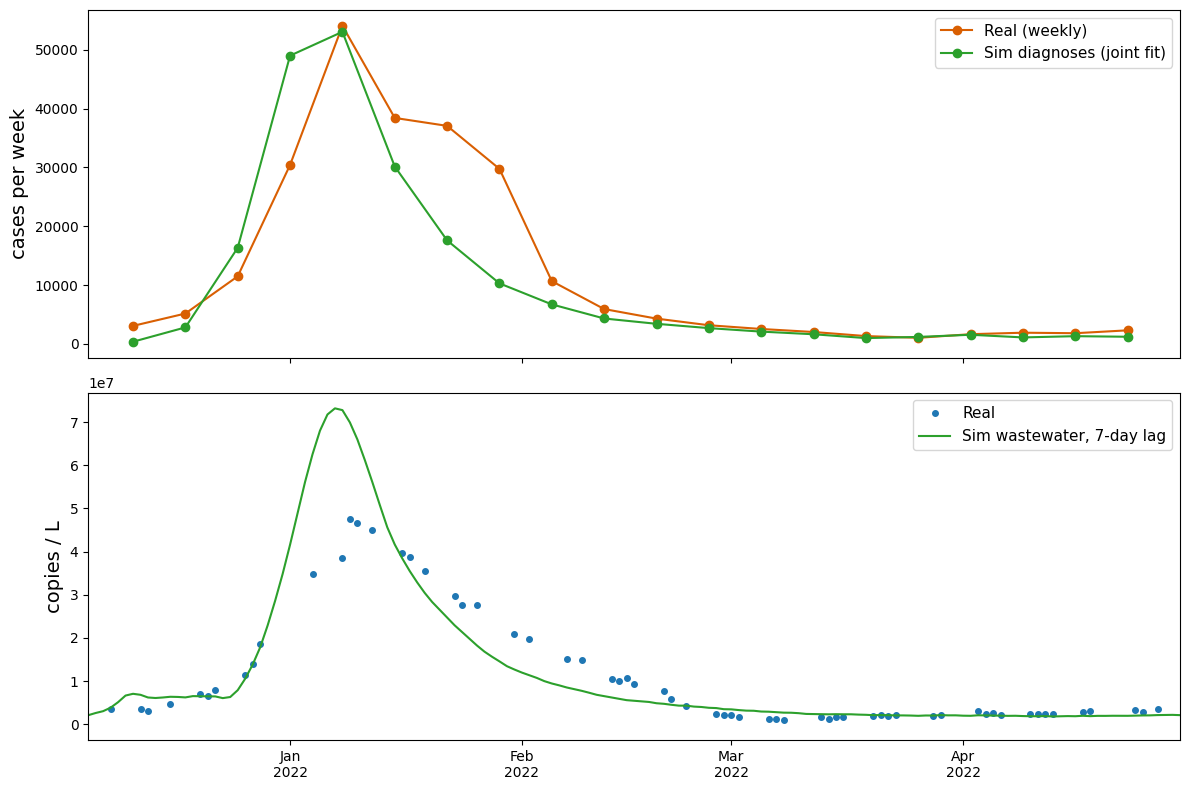

In [45]:
SIM_START = pd.Timestamp("2021-11-24")
bp6 = study6.best_params      # if the kernel restarted: study6 = optuna.load_study(study_name="pl_omicron_fit6_joint", storage=f"sqlite:///{OUT / 'optuna_pl_joint.db'}")

# 3-seed mean of daily sim wastewater and weekly diagnoses (no lag applied yet)
wwd = []
for seed in range(3):
    s = run_sim(bp6["beta"], bp6["symp_prob"], bp6["pop_infected"], bp6["immune_frac"], seed=seed)
    d = extract_wastewater_regression_data(s)
    d["date"] = pd.to_datetime(d["date"])
    wwd.append(d.set_index("date")["wastewater"])
ww_raw = pd.concat(wwd, axis=1).mean(axis=1)

wk6, _ = sim_outputs2(bp6["beta"], bp6["symp_prob"], bp6["pop_infected"], bp6["immune_frac"],
                      0, bp6["case_lag_days"], seeds=(0, 1, 2))

# Scan lags: for each, refit the scale constant and score the log-error on the real sample dates
scores = {}
for k in range(0, 16):
    on = ww_raw.shift(k, freq="D").reindex(ww_fit.index)
    ok = on.notna() & (on > 0)
    scores[k] = np.std(np.log(ww_fit[ok].values) - np.log(on[ok].values))
scores = pd.Series(scores)
best_k = int(scores.idxmin())
print(scores.round(3).to_string())
print("best lag:", best_k, "days")

ww_lag = ww_raw.shift(best_k, freq="D")
on = ww_lag.reindex(ww_fit.index); ok = on.notna() & (on > 0)
scale = np.exp(np.mean(np.log(ww_fit[ok].values) - np.log(on[ok].values)))

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax[0].plot(cases_obs.index, cases_obs.values, "o-", color="#D95F02", label="Real (weekly)")
ax[0].plot(wk6.index, wk6.values, "o-", color="tab:green", label="Sim diagnoses (joint fit)")
ax[0].set_ylabel("cases per week", fontsize=14); ax[0].legend(fontsize=11)

ax[1].plot(ww_fit.index, ww_fit.values, ".", ms=8, color="tab:blue", label="Real")
ax[1].plot(ww_lag.index, ww_lag * scale, "-", color="tab:green", label=f"Sim wastewater, {best_k}-day lag")
ax[1].set_ylabel("copies / L", fontsize=14); ax[1].legend(fontsize=11)
ax[1].set_xlim(ww_fit.index.min() - pd.Timedelta(days=3), ww_fit.index.max() + pd.Timedelta(days=3))
ax[1].xaxis.set_major_locator(mdates.MonthLocator())
ax[1].xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
plt.tight_layout(); plt.show()